In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip


# Walmart Store Sales Forecasting: Exploratory Data Analysis (EDA)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style("whitegrid")

path = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/"

train    = pd.read_csv(path + "train.csv.zip")
test     = pd.read_csv(path + "test.csv.zip")
features = pd.read_csv(path + "features.csv.zip")
stores   = pd.read_csv(path + "stores.csv")

print("train:", train.shape, "| test:", test.shape,
      "| features:", features.shape, "| stores:", stores.shape)

train: (421570, 5) | test: (115064, 4) | features: (8190, 12) | stores: (45, 3)


In [10]:
display(train.head(3))
display(test.head(3))
display(features.head(3))
display(stores.head(3))

print(train.dtypes)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392


Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object


## Merge (Join) Dataframes into one

In [11]:
def load_and_merge(df, features, stores):
    out = df.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
    out = out.merge(stores, on='Store', how='left')
    out['Date'] = pd.to_datetime(out['Date'])

    return out.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)


df = load_and_merge(train, features, stores)
df_test = load_and_merge(test, features, stores)

print(df.shape, df_test.shape)
df.head(3)

(421570, 16) (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315


# Data Analysis

In [12]:
print('Train Date range: ', df['Date'].min(), ' - ', df['Date'].max())
print('Test Date range: ', df_test['Date'].min(), ' - ', df_test['Date'].max())
print('Train weeks: ', df['Date'].nunique(), ' - Test weeks: ', df_test['Date'].nunique())

n_combinations = df.groupby(['Store', 'Dept']).ngroups
print('Unique store-dept series in train: ', n_combinations)
print('Stores: ', df['Store'].nunique(), ' - Depts: ', df['Dept'].nunique())

Train Date range:  2010-02-05 00:00:00  -  2012-10-26 00:00:00
Test Date range:  2012-11-02 00:00:00  -  2013-07-26 00:00:00
Train weeks:  143  - Test weeks:  39
Unique store-dept series in train:  3331
Stores:  45  - Depts:  81


- This tells us the shape of our data. train covers Feb 2010 - Oct 2012 (143 weeks), test covers Nov 2012 - Jul 2013 (39 weeks). So we are trying to forecast sales for 39 weeks.

## Store-Department Length Distribution 

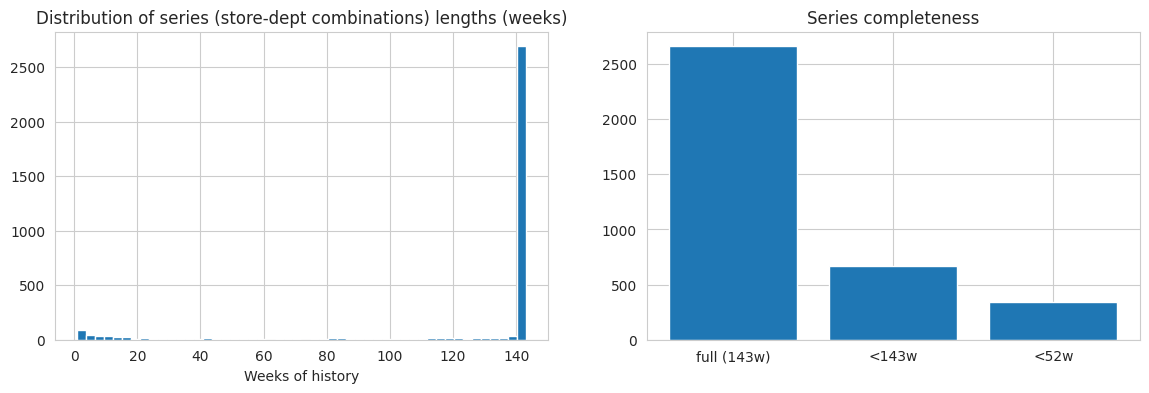

Series with full 143-week history: 2660
Series with < 52 weeks: 340
Series in test but not in train: 11


In [13]:
combinataions_len = df.groupby(['Store', 'Dept']).size()

fig, ax = plt.subplots(1, 2, figsize=(14,4))
combinataions_len.hist(bins=50, ax=ax[0])
ax[0].set_title('Distribution of series (store-dept combinations) lengths (weeks)')
ax[0].set_xlabel('Weeks of history')

full = (combinataions_len == 143).sum()
mid = (combinataions_len < 143).sum()
short = (combinataions_len < 52).sum()
ax[1].bar(["full (143w)", "<143w", "<52w"], 
          [full , mid , short])
ax[1].set_title("Series completeness")
plt.show()


print(f"Series with full 143-week history: {full}")
print(f"Series with < 52 weeks: {short}")
print(f"Series in test but not in train: "
      f"{len(set(zip(df_test.Store, df_test.Dept)) - set(zip(df.Store, df.Dept)))}")

- Distribution Analysis (specially) for neural forecasting models, since they need similar windows while predicting. (a series with 20 weeks of history can't feed a 52 week window)

# Missing Values

train:  MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64
test:  MarkDown1         149
MarkDown2       28627
MarkDown3        9829
MarkDown4       12888
CPI             38162
Unemployment    38162
dtype: int64


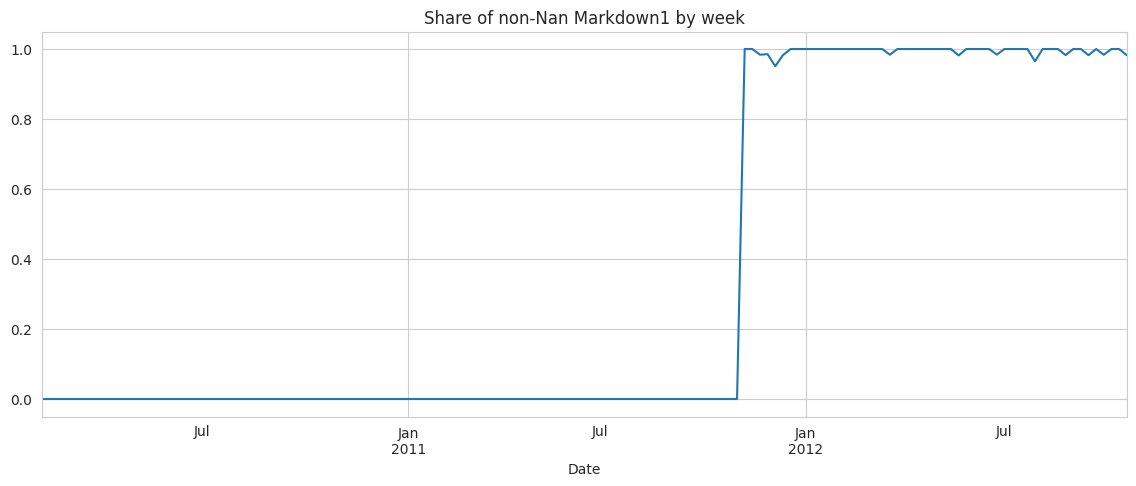

In [14]:
missing = df.isna().sum()
missing_test = df_test.isna().sum()

print('train: ', missing[missing > 0])
print('test: ', missing_test[missing_test > 0])

# analyze markdowns
md_presence = df.groupby('Date')['MarkDown1'].apply(lambda s : s.notna().mean())
md_presence.plot(title="Share of non-Nan Markdown1 by week")
plt.show()

- The plot shows why Walmart only started recording this data in Nov 2011.
Before that, the data simply doesn't exist. We can not just remove them, since we have to forecast each test case.

- CPI / Unemployment: missing in 38,162 test rows = **33% of the test set**
(the last ~13 weeks, May–Jul 2013) not yet published when the data was released.

# Target Variable Analysis

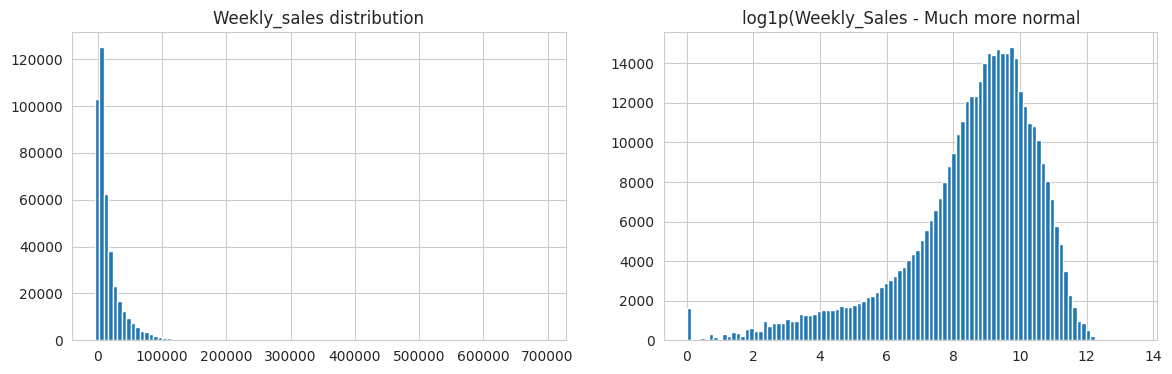

Negative sales rows: 1285 (0.305%)
count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))

df['Weekly_Sales'].hist(bins=100, ax=ax[0])
ax[0].set_title('Weekly_sales distribution')

np.log1p(df['Weekly_Sales'].clip(lower=0)).hist(bins=100, ax=ax[1])
ax[1].set_title("log1p(Weekly_Sales - Much more normal")
plt.show()

print('Negative sales rows:', (df['Weekly_Sales'] < 0).sum(),
      f"({(df['Weekly_Sales'] < 0).mean():.3%})")
print(df['Weekly_Sales'].describe())

- 2 Main findings from this Analysis, Sales are heavily right-skewed, a few giant department/weeks dominate and Negative sales exist (1285), these are returns exceeding sales. our decision is to keep them.

# Overal trend and Seasonality

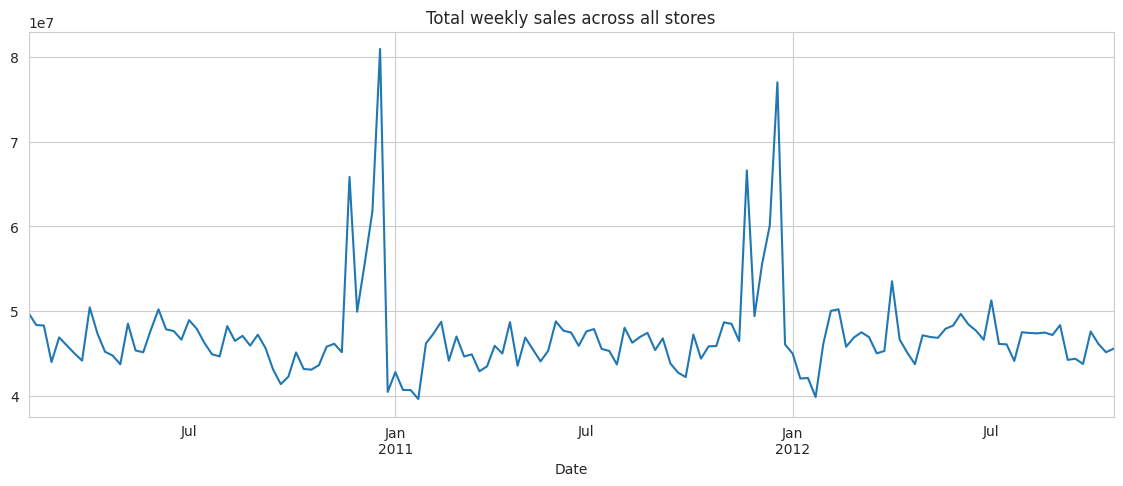

In [16]:
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()
weekly_total.plot(title='Total weekly sales across all stores')
plt.show()

- this plot shows us annual pattern with 2 massive spikes yeach year, thanksgiving and christmas week. stable other weeks. This shows the importance of all input windows.

# More Holiday Analysis

In [17]:
holidays = {
    "Super Bowl":   ["2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08"],
    "Labor Day":    ["2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06"],
    "Thanksgiving": ["2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29"],
    "Christmas":    ["2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27"],
}

avg_hol = df[df["IsHoliday"]]["Weekly_Sales"].mean()
avg_reg = df[~df["IsHoliday"]]["Weekly_Sales"].mean()
print(f"Avg sales holiday week: {avg_hol:,.0f} | regular week: {avg_reg:,.0f} "
      f"| lift: {avg_hol/avg_reg - 1:.1%}")

for name, dates in holidays.items():
    m = df["Date"].isin(pd.to_datetime(dates))
    print(f"{name:14s} avg: {df.loc[m, 'Weekly_Sales'].mean():>10,.0f}")

Avg sales holiday week: 17,036 | regular week: 15,901 | lift: 7.1%
Super Bowl     avg:     16,378
Labor Day      avg:     15,882
Thanksgiving   avg:     22,221
Christmas      avg:     14,543


The four holidays are **not equal**:
- **Thanksgiving** week averages 22,221, a massive spike (Black Friday).
- **Christmas** week averages 14,543, **below a regular week (15,901)**

This is because people shop the week *before* Christmas. the labeled holiday week
(ending after Dec 25) captures the post-peak drop. So "holiday" does not always mean
"high sales", a model that naively boosts all holiday weeks will overshoot Christmas.
Since holiday weeks carry **5x weight in WMAE**, handling each holiday individually
(separate flags, "weeks until Christmas" feature) matters more than the generic
`IsHoliday` column.

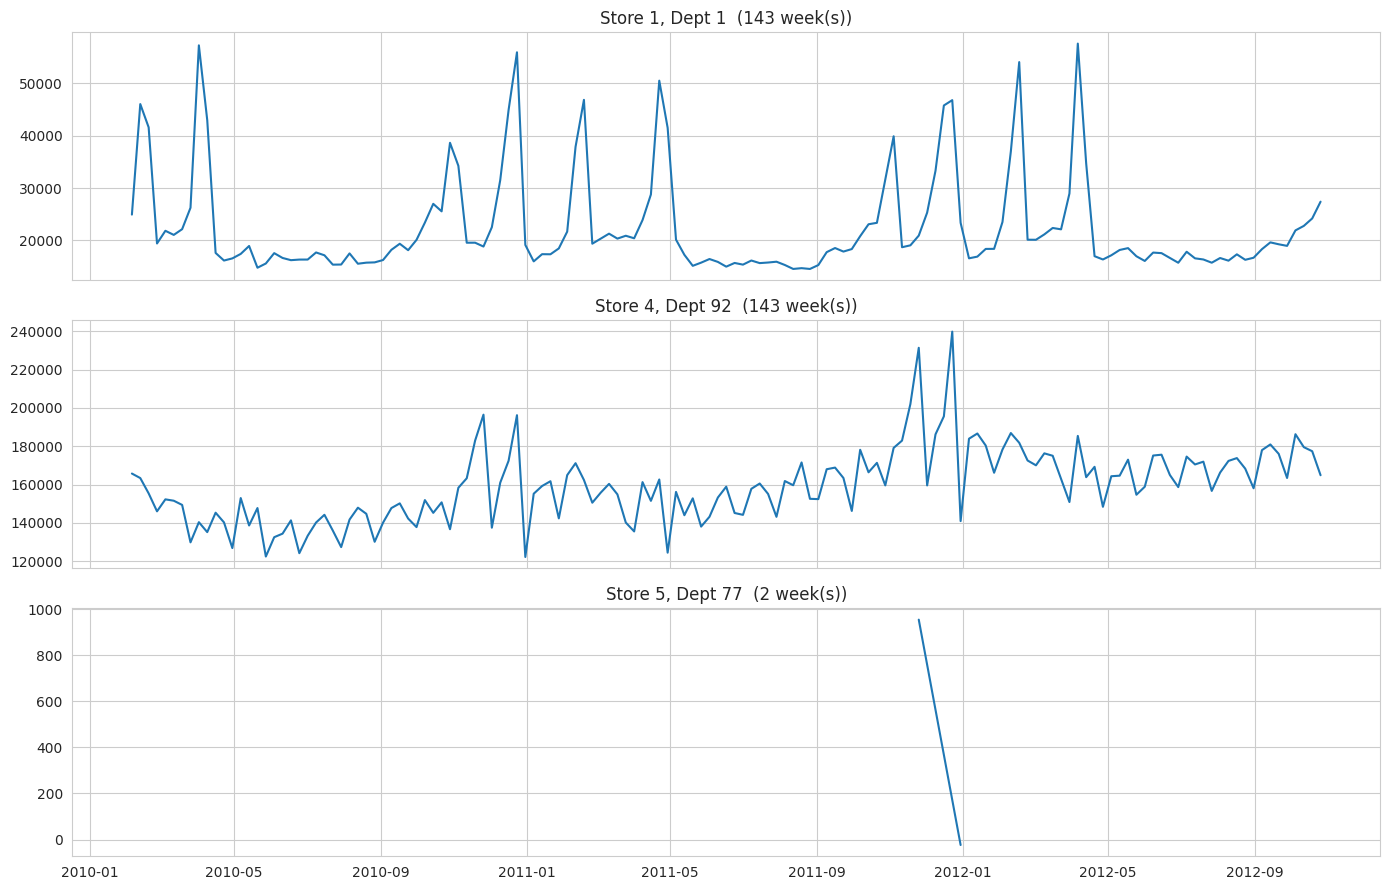

In [18]:
examples = [(1, 1), (4, 92), (5, 77)]   # adjust after looking: a big, a seasonal, a sparse one
fig, axes = plt.subplots(len(examples), 1, figsize=(14, 9), sharex=True)
for ax, (s, d) in zip(axes, examples):
    sub = df[(df.Store == s) & (df.Dept == d)]
    ax.plot(sub["Date"], sub["Weekly_Sales"])
    ax.set_title(f"Store {s}, Dept {d}  ({len(sub)} week(s))")
plt.tight_layout(); plt.show()

- Aggregate plots hide how diverse individiual series are, some are smooth and some are pure noise, some are near zero with random spikes.

# Store Types

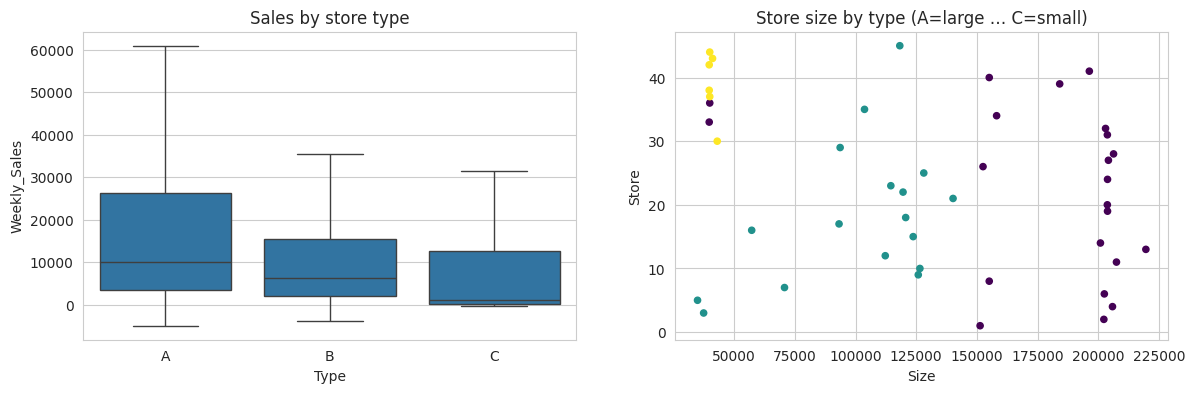

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df, x="Type", y="Weekly_Sales", showfliers=False, ax=ax[0])
ax[0].set_title("Sales by store type")
stores.plot.scatter(x="Size", y="Store", c=stores["Type"].map({"A":0,"B":1,"C":2}),
                    cmap="viridis", ax=ax[1], colorbar=False)
ax[1].set_title("Store size by type (A=large … C=small)")
plt.show()

- here we check if store's type and size matter predicting sales. Type A stores are large and sell the most, B medium and C small with lowest sales.

# Feature Correlation with Sales

In [20]:
numeric_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']
corr = df[numeric_cols + ['Weekly_Sales']].corr()['Weekly_Sales'].sort_values()
print(corr)

Unemployment   -0.025864
CPI            -0.020921
Temperature    -0.002312
Fuel_Price     -0.000120
Size            0.243828
Weekly_Sales    1.000000
Name: Weekly_Sales, dtype: float64


- Store Size shows a moderate positive correlation with sales (0.24). larger stores sell more, consistent with the store type finding above.
- Temperature, Fuel_Price, CPI, and Unemployment show almost no linear correlation with sales (all under 0.03). These macro/weather features are unlikely to be strong predictors on their own, though they may still help tree models pick up small non-linear interactions.

# Markdown Effect on Sales

In [21]:
MD_COLS = [f"MarkDown{i}" for i in range(1, 6)]
has_md = (df[MD_COLS].sum(axis=1) > 0)
print(df.groupby(has_md)['Weekly_Sales'].mean())
print(df.groupby(has_md)['Weekly_Sales'].count())

False    15871.522017
True     16177.015244
Name: Weekly_Sales, dtype: float64
False    270138
True     151432
Name: Weekly_Sales, dtype: int64


- Weeks with active markdowns show slightly higher average sales (16,177) than weeks without (15,871), roughly a 1.9% lift. The effect is present but modest, not a dramatic jump.
- Markdowns are active in about 36% of rows (151,432 out of 421,570) once they start being recorded (Nov 2011 onward), so this isn't a rare event: worth keeping as a feature, but not expected to be a dominant predictor on its own.

# Department-Level Analysis

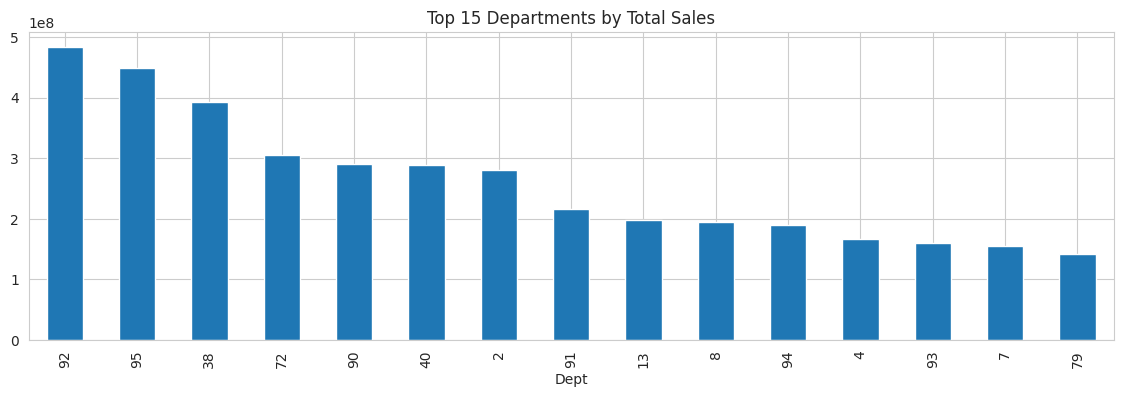

Number of unique departments: 81
Smallest 5 depts by total sales:
Dept
51    30572.83
78     1714.71
39      177.98
43       14.32
47    -4962.93
Name: Weekly_Sales, dtype: float64


In [22]:
dept_sales = df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14,4))
dept_sales.head(15).plot(kind='bar', ax=ax)
ax.set_title('Top 15 Departments by Total Sales')
plt.show()

print("Number of unique departments:", df['Dept'].nunique())
print("Smallest 5 depts by total sales:")
print(dept_sales.tail(5))

- Sales are heavily concentrated in a handful of departments: the top department (Dept 92) alone generated roughly 5x more total sales than departments ranked around #15.
- Out of 81 unique departments, several (51, 78, 39, 43) have very small total sales, suggesting they're rare, minor, or only present in a few stores/weeks.
- Dept 47 has a negative total sales value overall, meaning returns/negative entries outweighed actual sales across the whole dataset for this department: worth treating as a genuine outlier/edge case in modeling rather than a data error.

In [23]:
train_pairs = set(zip(train['Store'], train['Dept']))
test_pairs = set(zip(test['Store'], test['Dept']))

cold_start = test_pairs - train_pairs
print("Cold-start (Store,Dept) combos:", len(cold_start))
print("Total test combos:", len(test_pairs))
print(f"Percentage: {len(cold_start)/len(test_pairs)*100:.2f}%")

Cold-start (Store,Dept) combos: 11
Total test combos: 3169
Percentage: 0.35%


- Only 11 out of 3,169 Store-Dept combinations in the test set (0.35%) have zero training history: a negligible cold-start problem.
- Given the small scale, a simple fallback (e.g. department-level average, or store-level average if the department also doesn't exist) is sufficient: no need for a complex imputation strategy.

# Shared Preprocessing Decisions (For all model notebooks)

1. **Merge**: `load_and_merge()` as defined above (merge on Store, Date, IsHoliday).
2. **MarkDown1–5 NaN** : fill with 0 (structural missingness = no promotion).
3. **CPI / Unemployment NaN** : forward-fill per store.
4. **Negative sales** : keep in training; clip final *predictions* to ≥ 0.
5. **Validation split**: 39-week window shifted 52 weeks before test start
   (VALIDATION_START ≈ 2011-11-04, VALIDATION_END ≈ 2012-07-27), chosen to match
   the test set's holiday composition (Thanksgiving, Christmas, Super Bowl),
   not just its length. The plain "last 39 weeks of train" (Feb–Oct 2012) was
   rejected because it only contains Super Bowl and Labor Day, holidays with
   almost no sales lift, and completely misses Thanksgiving (+40%) and
   Christmas (-8.5%), the two 5x-weighted weeks that actually drive WMAE.
6. Final models should be **retrained on the full training set** (including
   the Aug–Oct 2012 weeks excluded from validation) before generating actual
   test predictions.
7. **Metric**: WMAE (holiday weeks weight 5) : function below.
8. **Cold-start series** (in test, not in train: 11 series, 0.35% of test combos,
   see Department-Level Analysis above): shared `coldstart_fallback()` below 
   median `Weekly_Sales` of the same Dept across same-Type stores (last 52 train
   weeks); 0 if the Dept is entirely unseen; clipped ≥ 0. Every model's test
   predictions for these rows are overwritten with this fallback (identical in
   all notebooks).


## Shared Preprocessig + Metric Functions

In [24]:
MD_COLS = [f"MarkDown{i}" for i in range(1, 6)]
VALIDATION_START = df_test['Date'].min() - pd.Timedelta(weeks=52)  
VALIDATION_END   = VALIDATION_START + pd.Timedelta(weeks=39)         

def preprocess(df):
    """Apply shared cleaning decisions. Input: merged df from load_and_merge()."""
    out = df.copy()
    out[MD_COLS] = out[MD_COLS].fillna(0)
    out[["CPI", "Unemployment"]] = (
        out.groupby("Store")[["CPI", "Unemployment"]].ffill()
    )
    return out

def temporal_split(df):
    """Train / validation split mirroring the test horizon (39 weeks),
    shifted back 52 weeks so it covers the same holidays (Thanksgiving,
    Christmas, Super Bowl) as the real test set."""
    tr = df[df["Date"] <  VALIDATION_START]
    va = df[(df["Date"] >= VALIDATION_START) & (df["Date"] < VALIDATION_END)]
    return tr, va
    
def wmae(y_true, y_pred, is_holiday):
    """Competition metric: MAE with holiday weeks weighted 5x."""
    w = np.where(is_holiday, 5, 1)
    return np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w)

# quick sanity check
df_clean = preprocess(df)
tr, va = temporal_split(df_clean)
print("train:", tr["Date"].max(), tr.shape, "| val:", va["Date"].min(), va.shape)
assert df_clean[MD_COLS].isna().sum().sum() == 0

train: 2011-10-28 00:00:00 (267184, 16) | val: 2011-11-04 00:00:00 (115856, 16)


In [25]:
def coldstart_fallback(df_train, df_test):
    train_pairs = set(zip(df_train.Store, df_train.Dept))
    mask = ~pd.Series(list(zip(df_test.Store, df_test.Dept)), index=df_test.index).isin(train_pairs)
    cold = df_test[mask].copy()
    recent = df_train[df_train['Date'] >= df_train['Date'].max() - pd.Timedelta(weeks=52)]
    med = recent.groupby(['Type', 'Dept'])['Weekly_Sales'].median()
    cold['y_fallback'] = [med.get((t, d), 0.0) for t, d in zip(cold['Type'], cold['Dept'])]
    cold['y_fallback'] = cold['y_fallback'].clip(lower=0)
    return cold

cold = coldstart_fallback(df_clean, df_test)
n_series = cold.groupby(['Store', 'Dept']).ngroups
print(f'Cold-start rows: {len(cold)} | series: {n_series}')
print(cold['y_fallback'].describe())

Cold-start rows: 36 | series: 11
count      36.000000
mean      218.414167
std       837.966572
min         0.000000
25%        11.390000
50%        13.410000
75%        29.880000
max      3624.820000
Name: y_fallback, dtype: float64


**Usage in model notebooks** : after generating test predictions (`final_preds` = frame with Store, Dept, Date, Weekly_Sales):

```python
cold = coldstart_fallback(df_clean, df_test)
final_preds = final_preds.merge(
    cold[['Store', 'Dept', 'Date', 'y_fallback']],
    on=['Store', 'Dept', 'Date'], how='left'
)
final_preds['Weekly_Sales'] = final_preds['y_fallback'].combine_first(final_preds['Weekly_Sales'])
final_preds = final_preds.drop(columns='y_fallback')
```

Note: the first argument must be the **merged** train dataframe (`df_clean` / `df`. the function needs the `Type` column); the raw `train` frame won't work.

## EDA Conclusions
- ~3,300 Store-Dept series, 143 train weeks, 39 test weeks horizon
- Strong yearly seasonality; Thanksgiving and Christmas dominate (and are 5x-weighted)
- Validation split must match test's holiday composition, not just its length, a naive "last 39 weeks of train" window (Feb-Oct 2012) misses Thanksgiving/Christmas entirely; shifted window (Nov 2011-Jul 2012) fixes this.
- MarkDowns structurally missing pre-Nov-2011, 0-fill
- Store Size correlates moderately with sales (0.24); Temperature, Fuel_Price, CPI, Unemployment show almost no linear correlation
- Markdown weeks show a modest ~1.9% sales lift over non-markdown weeks
- Sales are concentrated in a handful of departments (81 unique total); Dept 47 has negative total sales overall, a genuine outlier worth flagging
- Cold-start series are negligible (11 series, 0.35% of test combos), handled by shared `coldstart_fallback()`: Dept median within same-Type stores (last 52 train weeks), 0 if Dept unseen, clipped ≥ 0
- Series highly heterogeneous: some smooth, some noisy, some near-zero with random spikes
- Global DL models (DLinear / N-BEATS / PatchTST) fit this setting; trees use lag/rolling features
- Shared: preprocess(), temporal_split(), wmae(), coldstart_fallback(): copied to all model notebooks